# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and UMAP
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

This cell loads all the necessary Python tools and modules for the pipeline. It adds the scripts directory to Python's search path so we can access our custom code, imports standard data analysis libraries (pandas, numpy, matplotlib), and loads all our custom modules from the `config/` and `scripts/` directories. The `importlib.reload()` calls ensure we always use the latest version of our code if we've made changes.

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Uncomment on GPU Cluster Runs
import warnings
warnings.filterwarnings('ignore')


# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

This cell sets all the important settings that control how the pipeline works. Key parameters include:
- **Time windows**: How far back to look for news (LOOKBACK_WINDOW = 336 hours = 2 weeks) and how far ahead to predict (FORECAST_HORIZON = 24 hours)
- **Target definition**: What counts as a significant price movement (SPREAD_DEADBAND = threshold in EUR/MWh)
- **Data splits**: How to divide data into training (70%), validation (20%), and test (10%) sets
- **Feature settings**: Whether to use UMAP (advanced) or PCA (simpler) for reducing embedding dimensions
- **Search settings**: How many parameter combinations to test

All values are loaded from configuration files to keep them organized and easy to change.

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = cfg.XGB_RANDOM_SEARCH_ITERS  # 80 iterations by default

# Data paths (relative to data directory)
NEWS_PATH = "../data/merged_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 3.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

This cell automatically detects what computing hardware is available on your machine (CUDA GPU, Apple Silicon GPU, or CPU) and configures optimal settings for that hardware. It determines the best batch size for processing data and sets up the right acceleration method for each task. This ensures the pipeline runs as fast as possible on your specific computer.

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ CUDA detected: NVIDIA H200 (139.7 GB)
  Optimal batch size: 512
  XGBoost tree method: hist • device: cuda
  Parallel jobs: 119

✓ Using device: CUDA (NVIDIA H200)
  Optimal batch size: 512


## 4. Stage 1: Data Ingestion

This cell loads and prepares the raw data files. It:
1. **Loads news articles** from CSV with publication timestamps
2. **Loads energy market data** including spot prices, day-ahead auction prices, and power load
3. **Cleans both datasets** by converting timestamps, removing missing values, and filtering by date
4. **Creates the prediction target** by calculating the price spread (difference between spot and auction prices) and classifying it into three categories: Long (+1), Neutral (0), or Short (-1)
5. **Builds historical features** like previous prices/loads from 24 hours and 1 week ago
6. **Adds time-based features** extracted from dates (hour, day of week, month, etc.)

The output is three clean dataframes ready for the next stages: news articles, energy data, and a master dataset combining everything.

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=None,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (141716, 4)
Energy telemetry shape: (43990, 5)
Baseline feature frame: (43798, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 4.65s
  CPU usage: 1.7% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.6 MB written
  GPU util: 0% • Mem util: 0% (0.67/140.40 GB)

✓ Data loaded successfully
  News articles: 141716
  Energy records: 43990
  Master records: 43798


### Inspect Data

This cell displays how the prediction targets are distributed across the three classes (Long/Neutral/Short). It shows both the raw counts and percentages, helping you understand if the dataset is balanced or if one class is much more common than others. This is important because imbalanced classes can affect model training.

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    19961
 1.0    18966
 0.0     4871
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    45.575140
 1.0    43.303347
 0.0    11.121512
Name: proportion, dtype: float64


In [6]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    19961
 1.0    18966
 0.0     4871
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    45.575140
 1.0    43.303347
 0.0    11.121512
Name: proportion, dtype: float64


## 5. Stage 2A: Zero-Shot Topic Classification

This cell uses an AI model to automatically categorize each news article into energy-related topics without needing labeled training data. It works in two stages:
1. **Stage 1**: Routes each article to a broad category (e.g., "Supply," "Demand," "Fuel Prices")
2. **Stage 2**: Selects the specific topic within that category

Articles classified as "other" (not energy-related) are re-attempted using article descriptions. The result is each article labeled with a topic (e.g., "rising gas prices," "supply disruptions") and a confidence score. This transforms unstructured news text into structured categories the model can use.

In [7]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    classification_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        model_name=cfg.ZEROSHOT_MODEL,
        hierarchical_topic_groups=cfg.HIERARCHICAL_TOPIC_GROUPS,
        routing_settings=cfg.HIERARCHICAL_ROUTING_SETTINGS,
    )

news_df = classification_results['news_df']

print(f"\n✓ Classification complete")
print(f"  Unique topics: {news_df['classification'].nunique()}")
print(f"  Articles with classification: {news_df['classification'].notna().sum()}")



[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cuda:0


Processing 141715 texts with batch_size=512
Processing 40909 texts with batch_size=512
Processing 12313 texts with batch_size=512
Processing 4730 texts with batch_size=512
Processing 21028 texts with batch_size=512
Processing 1667 texts with batch_size=512
Processing 3542 texts with batch_size=512
Processing 4797 texts with batch_size=512
Processing 1013 texts with batch_size=512


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processing 225 texts with batch_size=512
Processing 376 texts with batch_size=512
Processing 56773 texts with batch_size=512
Processing 10684 texts with batch_size=512
Processing 3476 texts with batch_size=512
Processing 1010 texts with batch_size=512
Processing 898 texts with batch_size=512
Processing 3532 texts with batch_size=512
Processing 490 texts with batch_size=512
Processing 1601 texts with batch_size=512
Processing 259 texts with batch_size=512
Processing 803 texts with batch_size=512
Processing 155 texts with batch_size=512
Classification completed: 141716 articles processed
Articles classified as 'other': 32595 (23.0%)

Classification distribution:
classification
Sport, Unterhaltung, Kultur oder Lokalnachrichten ohne Wirtschaftsbezug                     32595
Innenpolitik, Regierungsbildung oder Wahlen                                                 31234
Krieg, Sanktionen, Terrorgefahr oder geopolitische Spannungen                               19395
Energiepolitik, Klimag

## 6. Stage 2B: Sentence Embeddings

This cell converts news article titles into numerical vectors called "embeddings" - think of them as numeric codes that capture the meaning of the text. It uses a pre-trained language model to transform each title into a 384-dimensional vector where similar articles have similar vectors. The process uses GPU acceleration when available for speed and caches results to avoid recomputing them later. These embeddings allow the machine learning model to understand the semantic content of news.

In [8]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model converted to fp16 (half precision) for CUDA acceleration
CUDA optimizations enabled: batch_size=512
Using batch_size=512 for embedding computation on device=cuda


Batches:   0%|          | 0/277 [00:00<?, ?it/s]

Embeddings computed: shape (141716, 384)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 23.24s
  CPU usage: 2.6% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +459.7 MB written
  GPU util: 0% • Mem util: 0% (2.31/140.40 GB)

✓ Embeddings computed
  Embedding dimension: 384


In [9]:
import random

# Print out a random sample of 50 headlines whose categories are "other"
other_label = cfg.OTHER_LABEL if hasattr(cfg, 'OTHER_LABEL') else "kein Bezug zu Energie, Wetter oder Finanzmärkten"

other_news = news_df[news_df["classification"] == other_label]

sample_size = min(50, len(other_news))
sampled_other = other_news.sample(n=sample_size, random_state=42) if sample_size > 0 else other_news

print("\nRandom sample of 50 headlines categorized as 'other':\n")
for idx, row in sampled_other.iterrows():
    print(f"- {row.get('title', '[No Title]')}")



Random sample of 50 headlines categorized as 'other':

- Corona-Pandemie: Deutschland fährt seine Impfkampagne gegen die Wand
- E-Commerce: Händler Temu verstößt gegen EU-Regeln zum Verbraucherschutz
- RWE darf Grundstücke von Landwirt in Lützerath abbaggern
- „Die Stadt ist weiter im Schmerz“: Butscha ein Jahr nach dem russischen Massaker
- Enormer Schaden: Dobrindt will aufrüsten gegen Cyberkriminelle
- „Die Infrastruktur für Pegasus ist auch in Deutschland da“
- Alexander King und Josephine Thyrêt führen BSW: Wagenknecht-Bündnis gründet Berliner Landesverband
- Energie: Göring-Eckardt schließt Streckbetrieb von AKWs nicht aus
- Jährlicher Umsatz von 6,5 Milliarden Euro - Fridays for Future-Effekt sorgt für neuen Boom bei Sägewerken
- Der US-Bevölkerungsschwerpunkt tendiert in diesem Jahrzehnt in Richtung Süden
- Die Wirtschaftsaussichten für die USA wurden von der OECD nach unten korrigiert, da Trumps Zölle das globale Wachstum auf den Kopf stellen
- Neue Zahlen zu Langzeitarbeitsl

## 7. Plot Comprehensive EDA Dashboard

These cells create visualizations to explore the data. The first generates a comprehensive dashboard showing target distributions, price spreads, news volumes, energy load patterns, and temporal patterns (hourly, daily trends). The second plots the embedding quality using UMAP and t-SNE - two techniques that create 2D scatter plots where similar news articles appear close together. If articles from the same topic cluster together, it means the embeddings are capturing meaningful patterns.

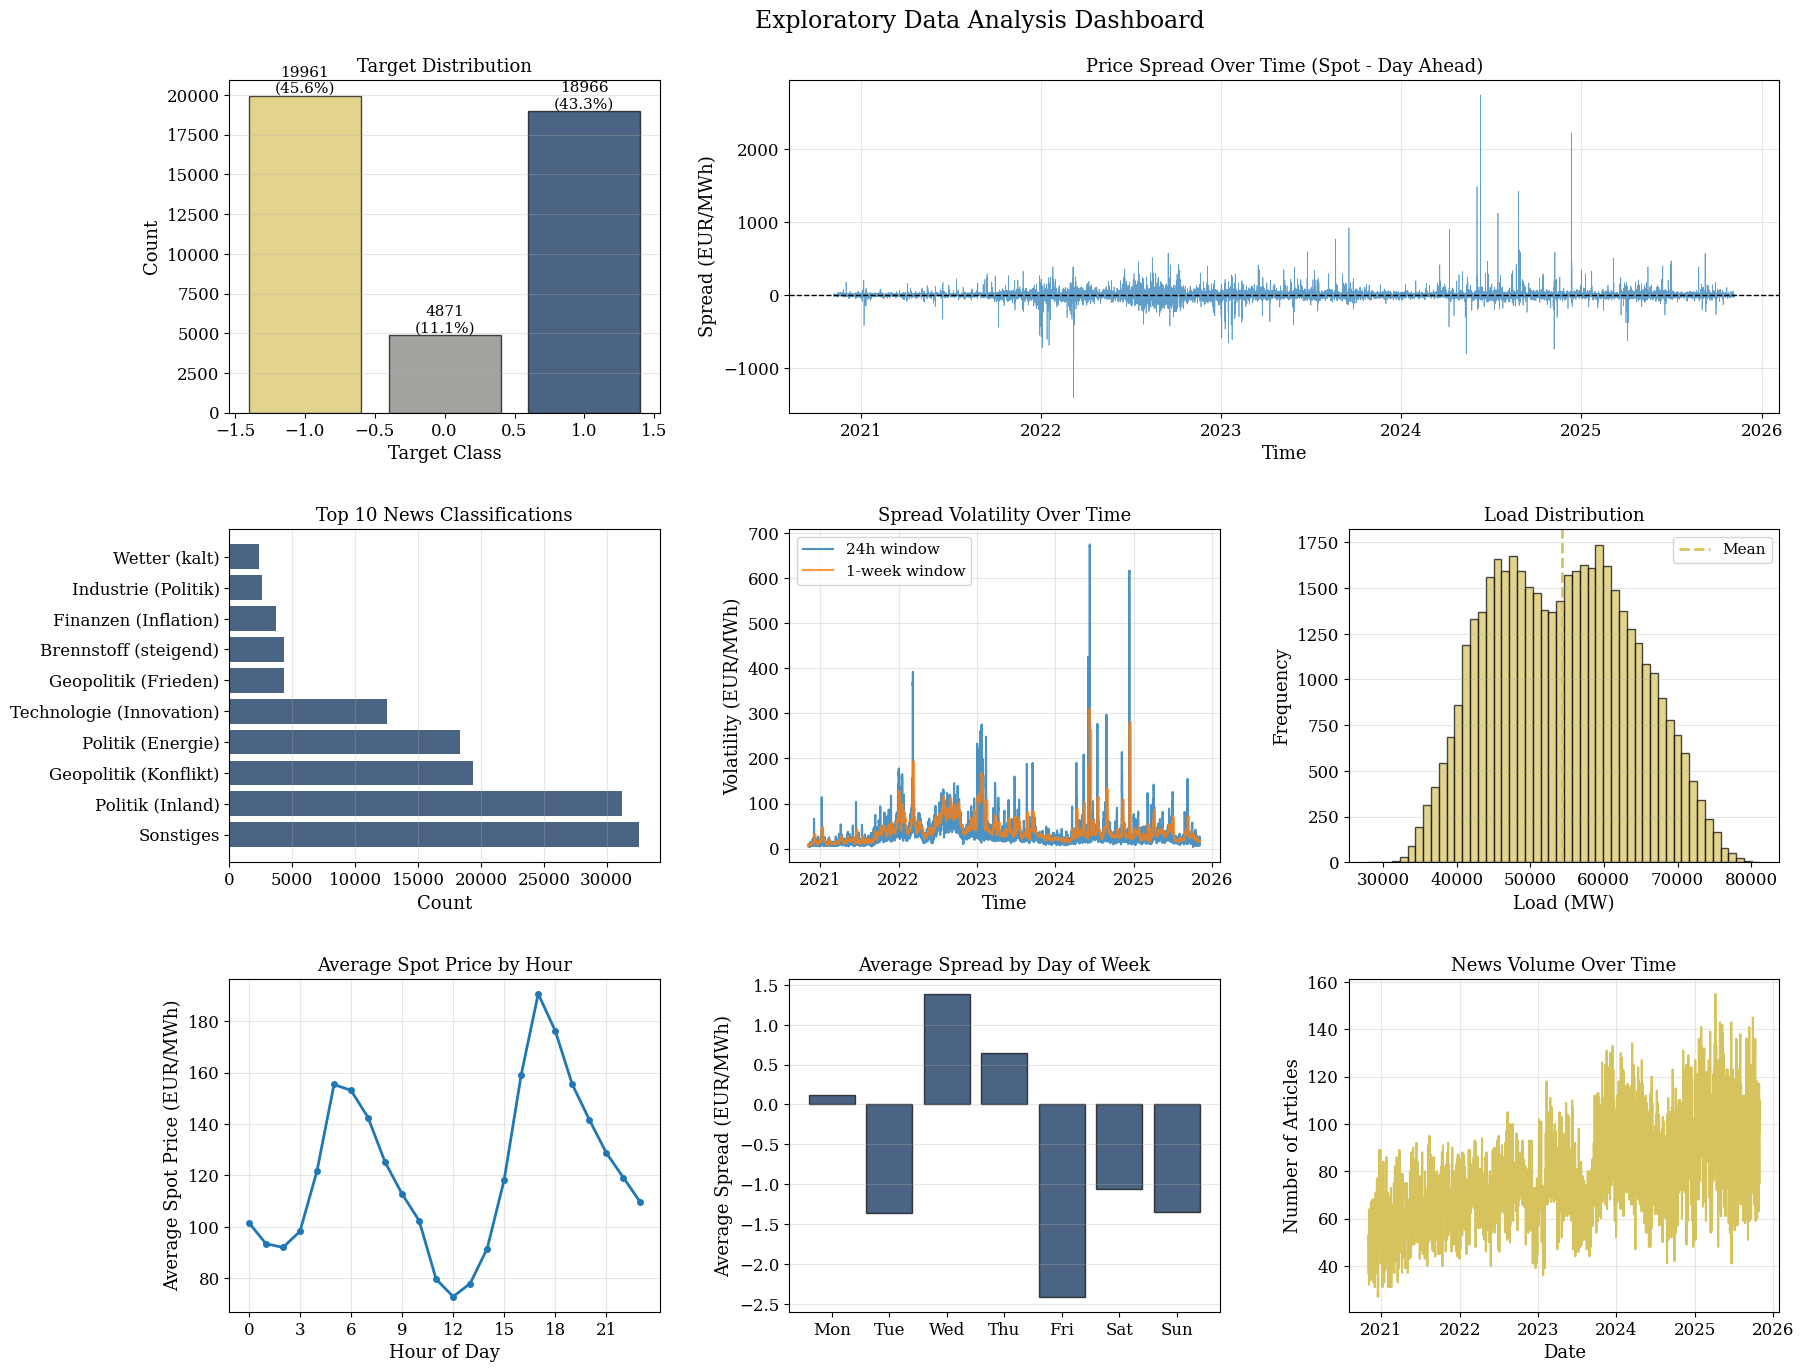

Figure saved: outputs/figures/embedding_quality_umap.png


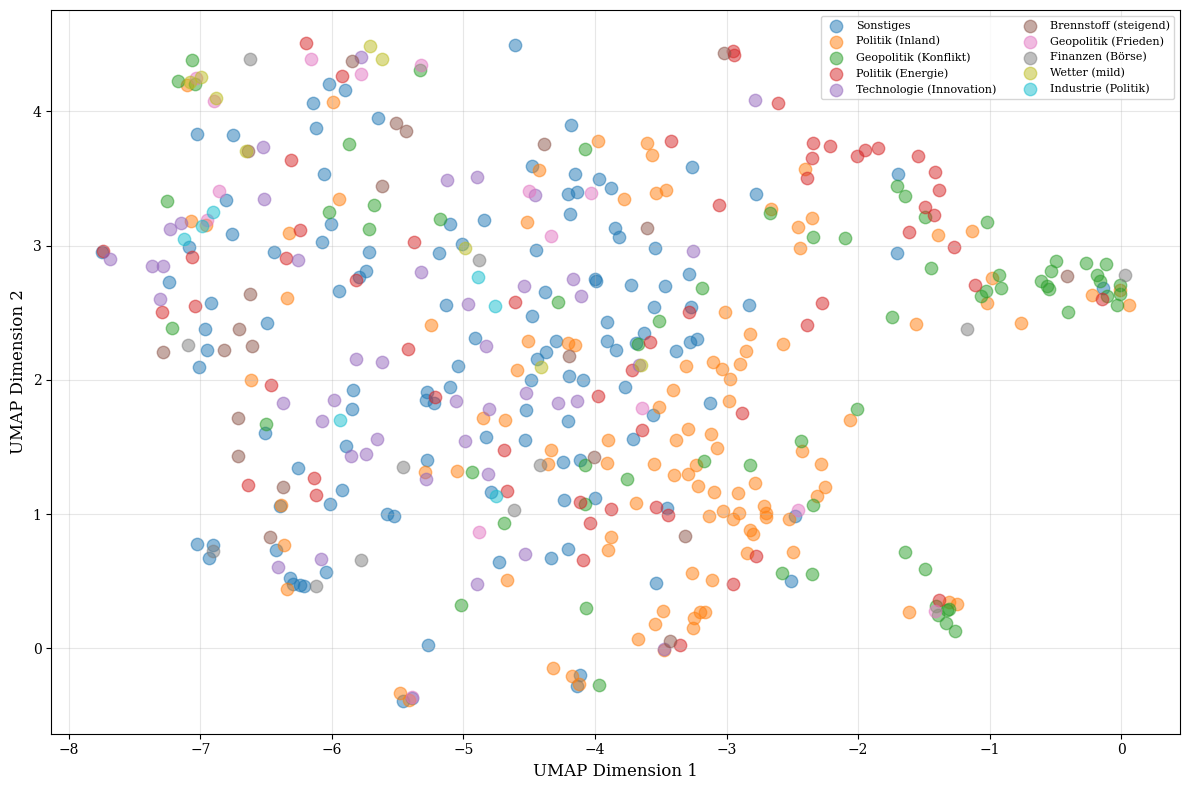

In [10]:
visualization.plot_eda_dashboard(master_df=master_df, news_df=news_df)
visualization.plot_embedding_quality(news_df=news_df, n_samples=500, save_path="embedding_quality_umap")

Generating individual EDA plots for publication...
Figure saved: outputs/figures/top_news_classifications.png


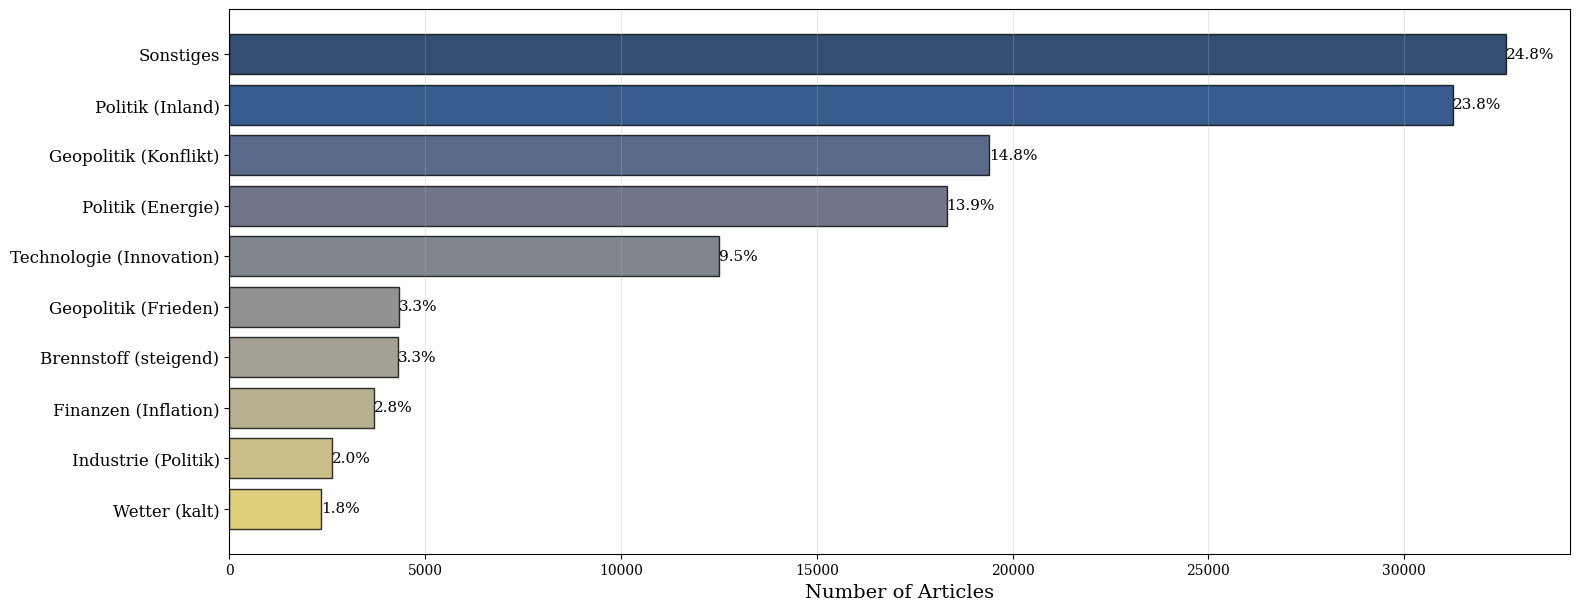

Figure saved: outputs/figures/target_distribution.png


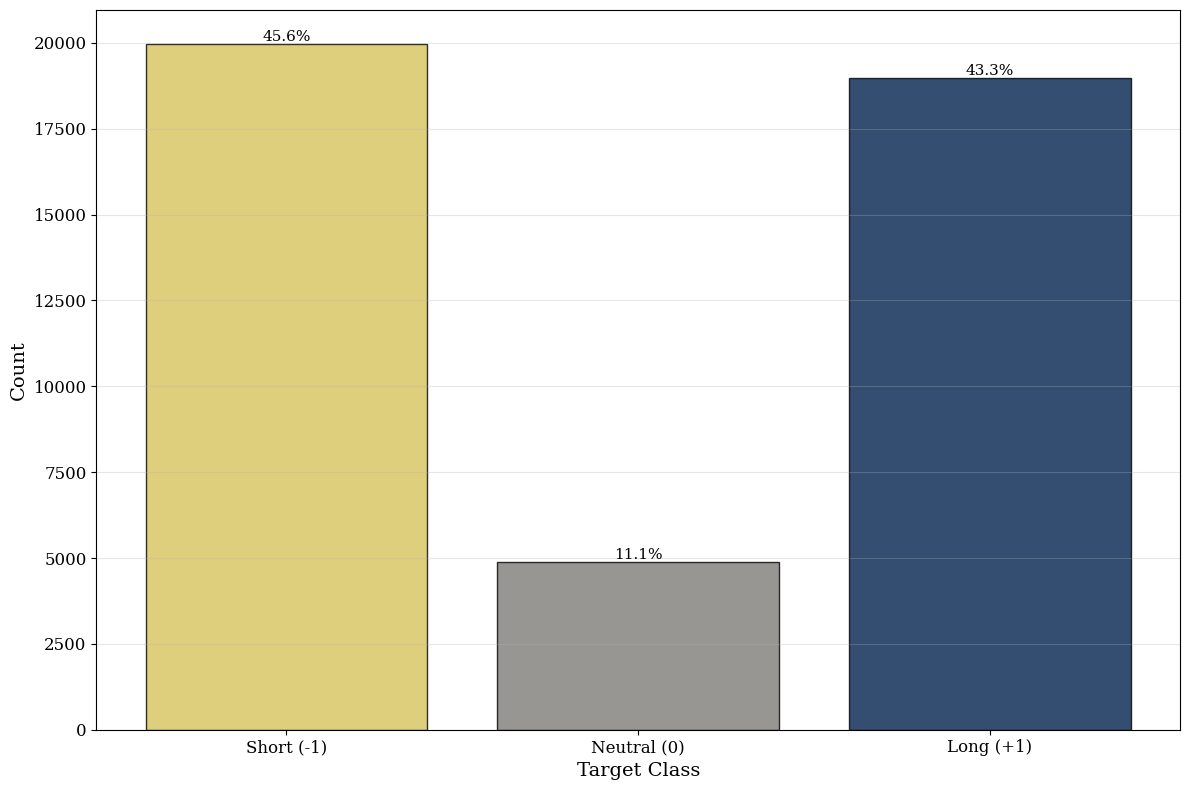

Figure saved: outputs/figures/top_news_sources.png


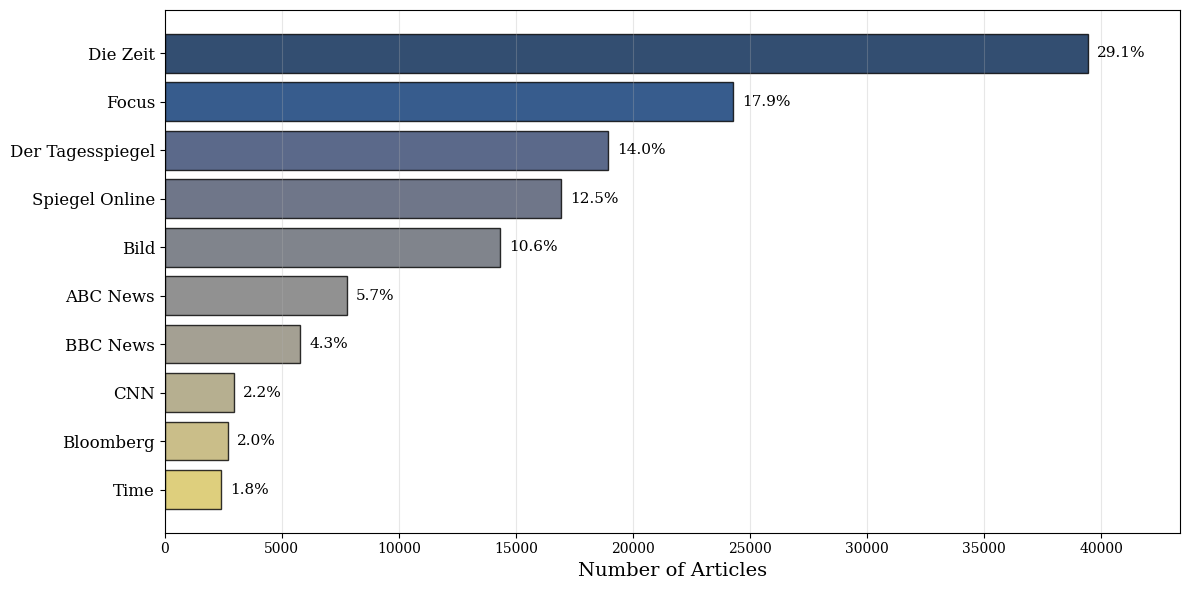

Figure saved: outputs/figures/news_hourly_coverage.png


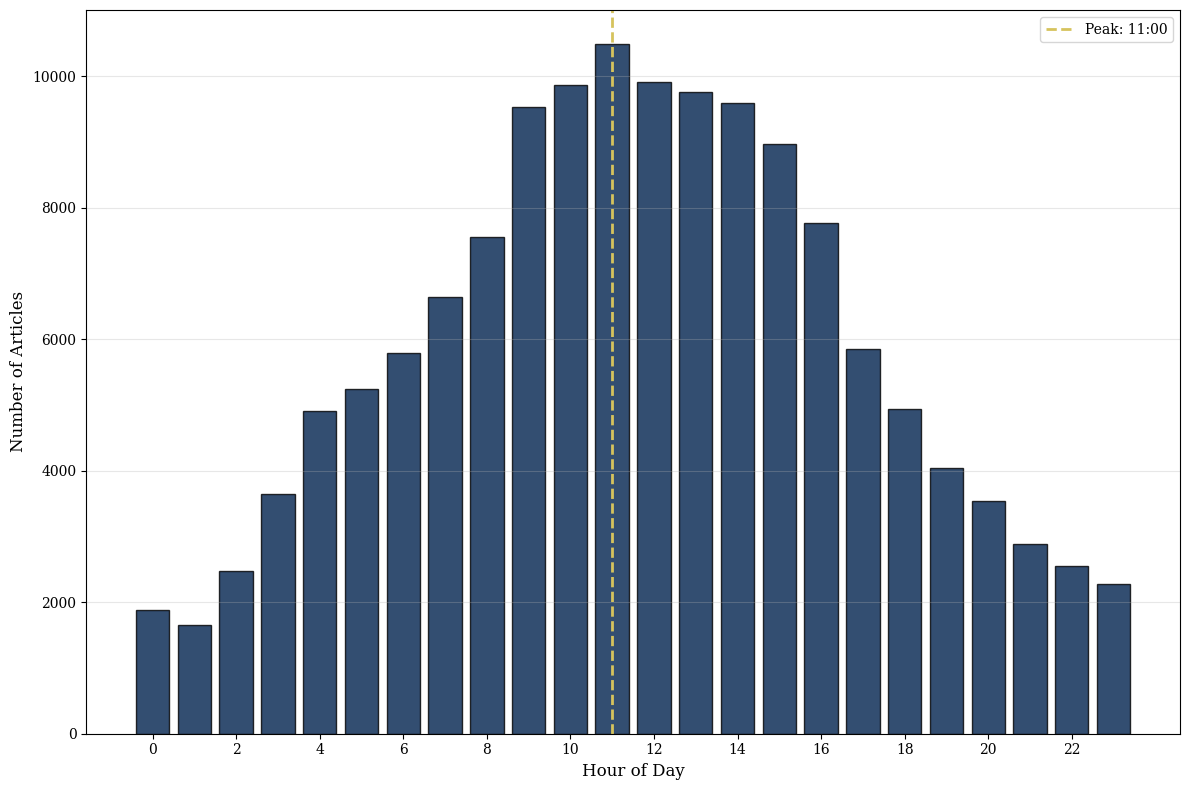

Figure saved: outputs/figures/news_coverage_volume.png


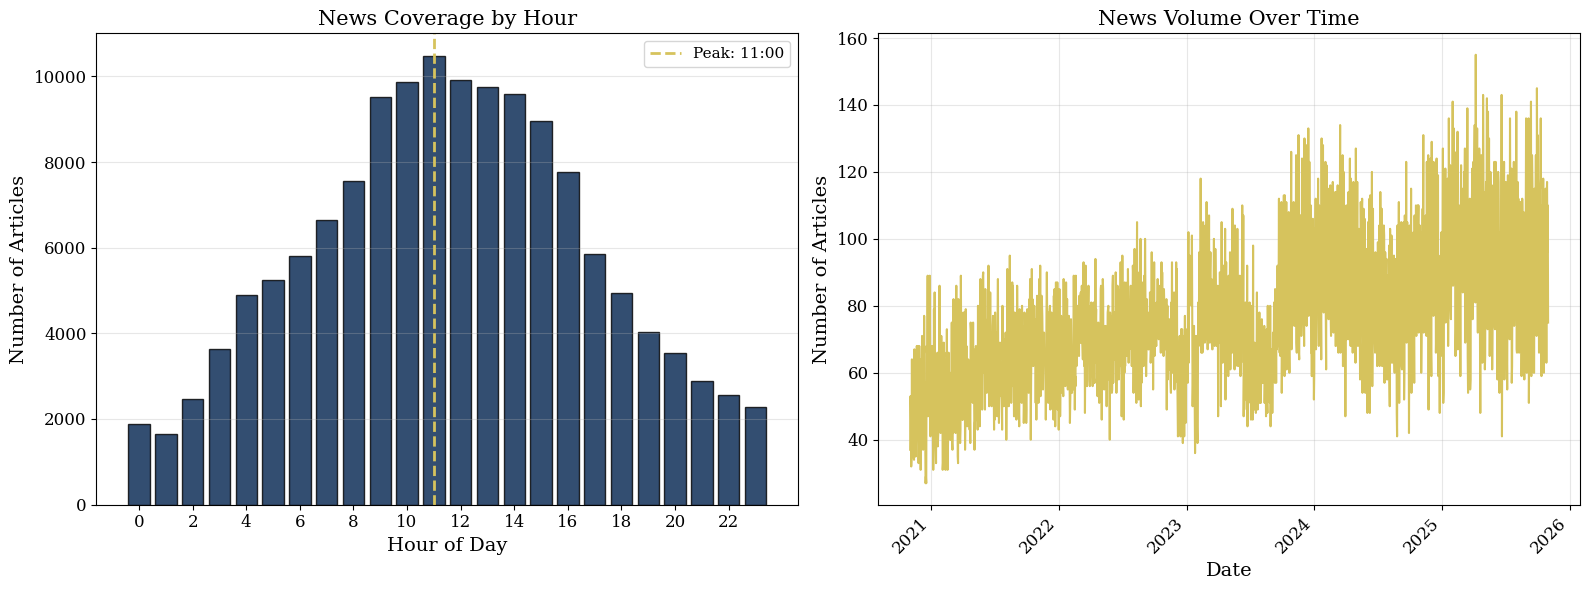


Figures saved to: outputs/figures/


In [11]:
# Individual EDA plots with file export for publication
print("Generating individual EDA plots for publication...")

# Top 10 news classifications
visualization.plot_top_news_classifications(
    news_df=news_df, 
    top_n=10, 
    save_path="top_news_classifications",
    show=True
)

# Target distribution
visualization.plot_target_distribution(
    master_df=master_df,
    target_column=cfg.TARGET_COLUMN,
    save_path="target_distribution",
    show=True
)

# Top 10 news sources
visualization.plot_top_news_sources(
    news_df=news_df,
    top_n=10,
    save_path="top_news_sources", 
    show=True
)

# Hourly news coverage
visualization.plot_news_hourly_coverage(
    news_df=news_df,
    save_path="news_hourly_coverage",
    show=True
)

# Combined News Coverage and Volume
visualization.plot_news_volume_and_coverage(
    news_df=news_df,
    save_path="news_coverage_volume",
    show=True
)


print(f"\nFigures saved to: {cfg.FIGURES_OUTPUT_DIR}/")

## 7B. News Event Analysis Visualizations

This cell generates academic-style visualizations analyzing the relationship between news events and price movements:

1. **Event Importance Heatmap**: Shows how different news topic types vary in importance (correlation with spread changes) over time periods, similar to Chakraborty et al. style analysis.

2. **News Shocks vs Price**: Dual-axis charts showing positive/negative news shock counts overlaid with price/spread series over time.


Computing time-decayed topic counts for event importance analysis...
Filtered 32595 'other' articles (no energy relevance) from time decay aggregation
Computing time-decayed counts for 43798 timestamps and 20 topics
Lookback window: 336h, decay lambda: 0.05
CuPy not available; using vectorized NumPy computation
Processing 109121 valid articles across 43798 timestamps
Using optimized binary search and vectorization


Processing timestamps: 100%|██████████| 43798/43798 [00:11<00:00, 3748.77it/s]



✓ Topic counts computed
  Shape: (43798, 20)
  Topics: 20
  Time range: 2020-11-08 00:00:00 to 2025-11-06 21:00:00

GENERATING EVENT IMPORTANCE HEATMAP
Figure saved: outputs/figures/event_importance_heatmap.png


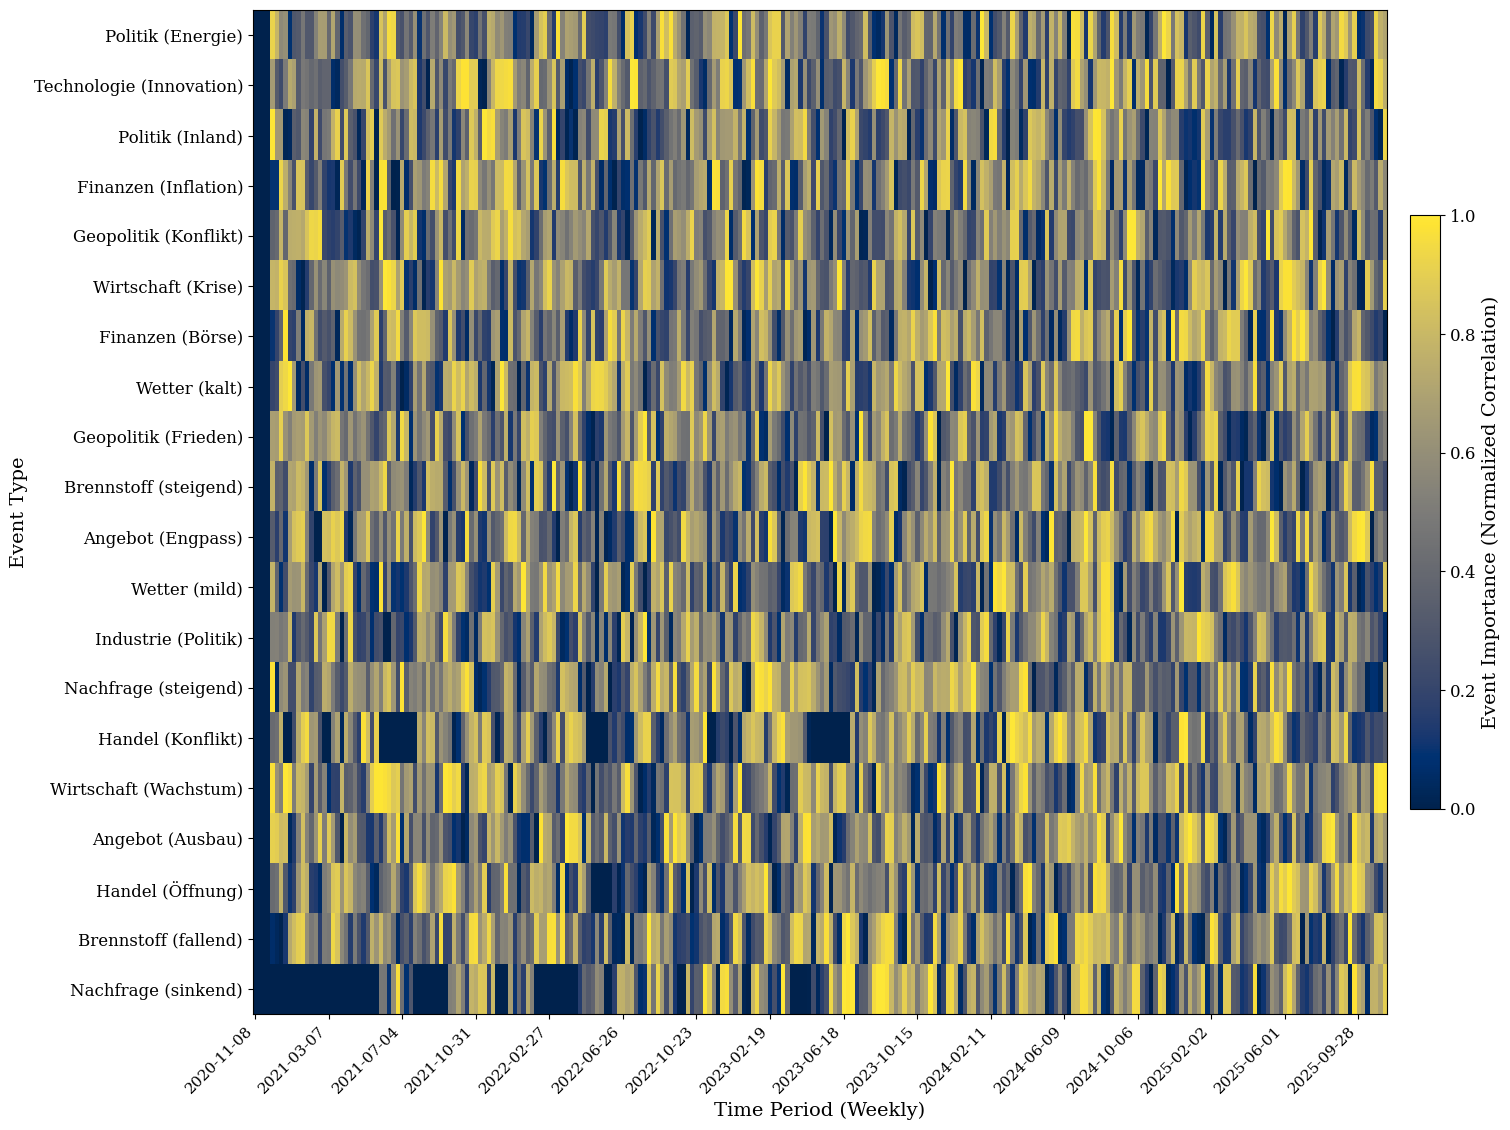


GENERATING NEWS SHOCKS VS PRICE CHART
Figure saved: outputs/figures/news_shocks_vs_price.png


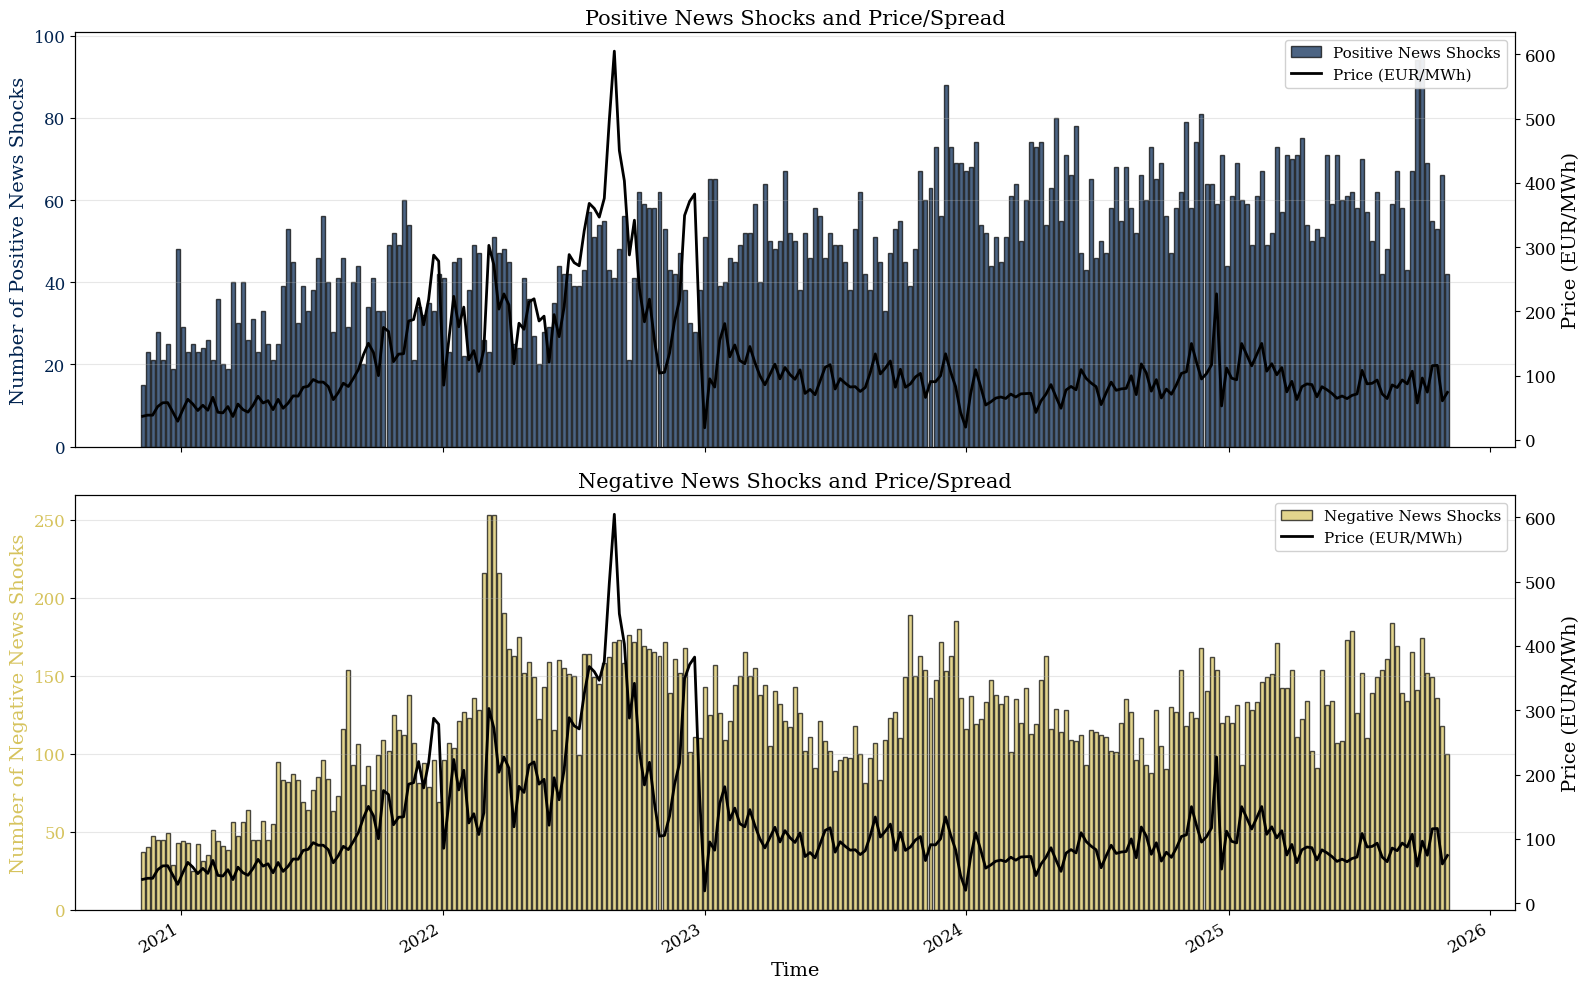


✓ Event analysis visualizations complete
  Figures saved to: outputs/figures/


In [12]:
# Compute time-decayed topic counts for visualization
# Use default parameters for consistency with feature engineering
print("Computing time-decayed topic counts for event importance analysis...")
topic_counts_df = fe.compute_time_decayed_topic_counts(
    news_df=news_df,
    master_df=master_df,
    lookback_window=cfg.DEFAULT_LOOKBACK_WINDOW,
    decay_lambda=cfg.DEFAULT_DECAY_LAMBDA,
    verbose=True,
    use_gpu=True
)

print(f"\n✓ Topic counts computed")
print(f"  Shape: {topic_counts_df.shape}")
print(f"  Topics: {len(topic_counts_df.columns)}")
print(f"  Time range: {topic_counts_df.index.min()} to {topic_counts_df.index.max()}")

# Generate event importance heatmap
print("\n" + "="*70)
print("GENERATING EVENT IMPORTANCE HEATMAP")
print("="*70)
visualization.plot_event_importance_heatmap(
    topic_counts_df=topic_counts_df,
    spread_series=master_df['real_spread_abs'],
    rolling_window_weeks=4,
    save_path="event_importance_heatmap",
    show=True
)

# Generate news shocks vs price chart
print("\n" + "="*70)
print("GENERATING NEWS SHOCKS VS PRICE CHART")
print("="*70)
visualization.plot_news_shocks_vs_price(
    news_df=news_df,
    spread_series=master_df['real_spread_abs'],
    price_series=master_df['Spot Price'],
    save_path="news_shocks_vs_price",
    show=True
)

print(f"\n✓ Event analysis visualizations complete")
print(f"  Figures saved to: {cfg.FIGURES_OUTPUT_DIR}/")


## 8. Stage 3: Feature Engineering - Time-Decay Aggregation

This cell creates time-weighted news features for each timestamp. For every hour in the energy data, it:
1. **Counts relevant news articles** for each topic within the lookback window (e.g., last 2 weeks)
2. **Averages article embeddings** to capture overall news sentiment
3. **Applies time decay**: Recent articles get more weight using the formula `weight = e^(-λ × hours_since)`, so a 1-day-old article counts more than a 1-week-old article
4. **Reduces embedding dimensions** from 384 to 20 using UMAP or PCA to simplify the data
5. **Tests multiple parameter combinations** (different lookback windows and decay rates) in parallel

This creates a library of feature sets with different time-weighting strategies to find which works best for prediction.

In [13]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 30 parameter combinations...
Parallelizing across parameter combinations using joblib (n_jobs=-1)...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 58 concurrent workers.


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed:  1.4min remaining: 13.0min


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


...

Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:  2.6min remaining:   17.5s


Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn
Embedding reduction backend: umap-learn


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  3.4min finished



✓ Completed precomputation of 30 parameter combinations
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 204.46s
  CPU usage: 7.7% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +184.4 MB written
  GPU util: 0% • Mem util: 0% (2.31/140.40 GB)

✓ Time-decay feature cache built
  Parameter combinations: 30
  Sample keys: [(24, 0.01), (24, 0.05), (24, 0.1)]


## 9. Stage 3B: Dataset Assembly

This cell combines the time-decay features with the baseline energy data and organizes everything into training, validation, and test sets. For each parameter combination tested earlier, it creates a complete dataset with all features merged together, removes any rows with missing values, and chronologically splits the data (preserving time order) into 70% training, 20% validation, and 10% test. The result is a collection of ready-to-use datasets, one for each parameter combination.

In [14]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=cfg.TRAIN_RATIO,
        val_ratio=cfg.VAL_RATIO,
        test_ratio=cfg.TEST_RATIO,
    )

# Select a sample dataset for inspection
sample_params_key = list(preprocessed_datasets.keys())[0]
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Total datasets: {len(preprocessed_datasets)}")
print(f"  Sample dataset: {sample_dataset['dataset_name']}")
print(f"  Train samples: {len(sample_dataset['train_df'])}")
print(f"  Val samples: {len(sample_dataset['val_df'])}")
print(f"  Test samples: {len(sample_dataset['test_df'])}")
print(f"  News features: {len(sample_dataset['news_features'])}")


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.51s
  CPU usage: 1.9% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.1 MB written
  GPU util: 0% • Mem util: 0% (2.31/140.40 GB)

✓ Dataset assembly complete
  Total datasets: 30
  Sample dataset: dataset_lw24_dl0.01
  Train samples: 30658
  Val samples: 8759
  Test samples: 4381
  News features: 40


## 11. Stage 3D: Feature Selection with RidgeCV

This cell tests which parameter combination (lookback window and decay rate) produces the best features for prediction. For each combination, it trains a Ridge classifier using expanding-window cross-validation (a time-series-safe method that gradually grows the training set). It measures validation accuracy and F1-score for each combination and ranks them. The top 5 combinations are selected for further testing with more sophisticated models. This step narrows down the massive parameter space to the most promising candidates.

In [15]:
# Define baseline features for XGBoost and upstream stages
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168", "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# Restrict LightGBM baseline inputs to price-only spread signals
lgbm_baseline_features = [
    "real_spread_abs",
    "Day Ahead Auction",
    "Spot Price",
]

# Get news feature definitions from sample dataset
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline: {len(baseline_features)}, Topics: {len(topic_features)}, Embeddings: {len(embedding_features)}, Total news: {len(news_features)}")

# Run Ridge feature selection across parameter combinations
with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_5_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_5_combinations:
    best_params_key = top_5_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(f"\n✓ Top parameter combination: {best_dataset['dataset_name']} (lookback={top_5_combinations[0]['lookback_window']}h, lambda={top_5_combinations[0]['decay_lambda']})")
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline: 13, Topics: 20, Embeddings: 20, Total news: 40

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 30 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 58 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed:    6.2s remaining:   56.0s
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed:    6.5s remaining:   21.5s
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed:    6.6s remaining:   11.4s
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed:    6.7s remaining:    6.7s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    6.9s remaining:    4.0s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:    6.9s remaining:    2.1s
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:    7.0s remaining:    0.8s


TOP 5 PARAMETER COMBINATIONS:
1. dataset=dataset_lw168_dl0.01 | lookback=168h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.516 | Val Macro-F1=0.362
2. dataset=dataset_lw504_dl0.01 | lookback=504h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.513 | Val Macro-F1=0.354
3. dataset=dataset_lw168_dl0.1 | lookback=168h | lambda=0.1 | alpha=1000.0000 | Val Accuracy=0.512 | Val Macro-F1=0.354
4. dataset=dataset_lw504_dl0.1 | lookback=504h | lambda=0.1 | alpha=100.0000 | Val Accuracy=0.510 | Val Macro-F1=0.357
5. dataset=dataset_lw48_dl0.5 | lookback=48h | lambda=0.5 | alpha=1000.0000 | Val Accuracy=0.509 | Val Macro-F1=0.358
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 7.30s
  CPU usage: 12.1% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.7 MB written
  GPU util: 0% • Mem util: 0% (2.31/140.40 GB)

✓ Top parameter combination: dataset_lw168_dl0.01 (lookback=168h, lambda=0.01)


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    7.2s finished


## 12. Stage 3E: Summarise Ridge Results

This cell displays a table showing the top 5 parameter combinations found in the previous step. For each combination, it shows the dataset name, lookback window (hours), decay lambda (decay rate), the best Ridge regularization strength (alpha), and validation performance metrics (accuracy and macro F1-score). This lets you quickly compare which settings worked best during preliminary screening.

In [16]:
# Display top 5 Ridge parameter combinations
if top_5_combinations:
    top_5_summary = pd.DataFrame([{
        "dataset_name": res["dataset_name"],
        "lookback_window": res["lookback_window"],
        "decay_lambda": res["decay_lambda"],
        "alpha": res["best_alpha"],
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
    } for res in top_5_combinations])
    display(top_5_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,dataset_lw168_dl0.01,168,0.01,1000.0,0.515926,0.361744
1,dataset_lw504_dl0.01,504,0.01,1000.0,0.512958,0.353622
2,dataset_lw168_dl0.1,168,0.10,1000.0,0.512045,0.353658
3,dataset_lw504_dl0.1,504,0.10,100.0,0.509533,0.357383
4,dataset_lw48_dl0.5,48,0.50,1000.0,0.509419,0.357842


## 13. Stage 4: Model Training - XGBoost with Random Search

**Note:** This stage trains a 3-class XGBoost classifier (Long/Neutral/Short) with proper handling of class imbalance and regularization.

This cell trains XGBoost models (powerful tree-based machine learning) on each of the top parameter combinations from the Ridge screening. For each combination it:
1. **Randomly tests 80 different hyperparameter settings** (tree depth, learning rate, number of trees, etc.)
2. **Uses expanding-window cross-validation** to properly handle time-series data without cheating
3. **Handles class imbalance** by giving more weight to rare classes using inverse-frequency sample weights
4. **Selects the best model** based on validation F1-score
5. **Calibrates probabilities** using the validation set to make confidence scores more reliable

The output is the single best-performing XGBoost model, which will be used later as a feature for an even more sophisticated model. A learning curve plot shows whether the model is learning well or overfitting.

In [17]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    xgb_results = model_utils.train_xgb_candidates(
        top_combinations=top_5_combinations if top_5_combinations else [],
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
        fallback_params_key=sample_params_key if not top_5_combinations else None,
        fallback_dataset=sample_dataset if not top_5_combinations else None
    )

# Extract results
xgb_tuning_runs = xgb_results["tuning_runs"]
xgb_best_models = xgb_results["best_models"]
xgb_feature_columns = xgb_results["feature_columns"]
xgb_label_encoders = xgb_results["label_encoders"]
best_xgb_run = xgb_results["best_run"]
best_xgb_params_key = xgb_results["best_params_key"]
best_xgb_model = xgb_results["best_model"]  # Calibrated model (used for LightGBM)
best_xgb_model_uncalibrated = xgb_results["best_model_uncalibrated"]  # Uncalibrated (for learning curves)
best_xgb_feature_columns = xgb_results["best_feature_columns"]
best_xgb_label_encoder = xgb_results["best_label_encoder"]
best_dataset = xgb_results["best_dataset"]


[Stage ⏳] Stage 4: XGBoost Random Search — starting
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#1 dataset_lw168_dl0.01 → CV F1=0.124, Val Acc=0.105, Val Macro-F1=0.065
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#2 dataset_lw504_dl0.01 → CV F1=0.124, Val Acc=0.104, Val Macro-F1=0.065
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#3 dataset_lw168_dl0.1 → CV F1=0.126, Val Acc=0.123, Val Macro-F1=0.093
Training XGBoost with 3 classes: [-1  0  1]
Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#4 da


COMPUTING LEARNING CURVES FOR XGBOOST 3-CLASS CLASSIFIER
This may take a few minutes...


/venv/main/lib/python3.10/site-packages/xgboost/core.py:774: UserWarning: [17:54:14] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/venv/main/lib/python3.10/site-packages/xgboost/core.py:774: UserWarning: [17:54:31] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before

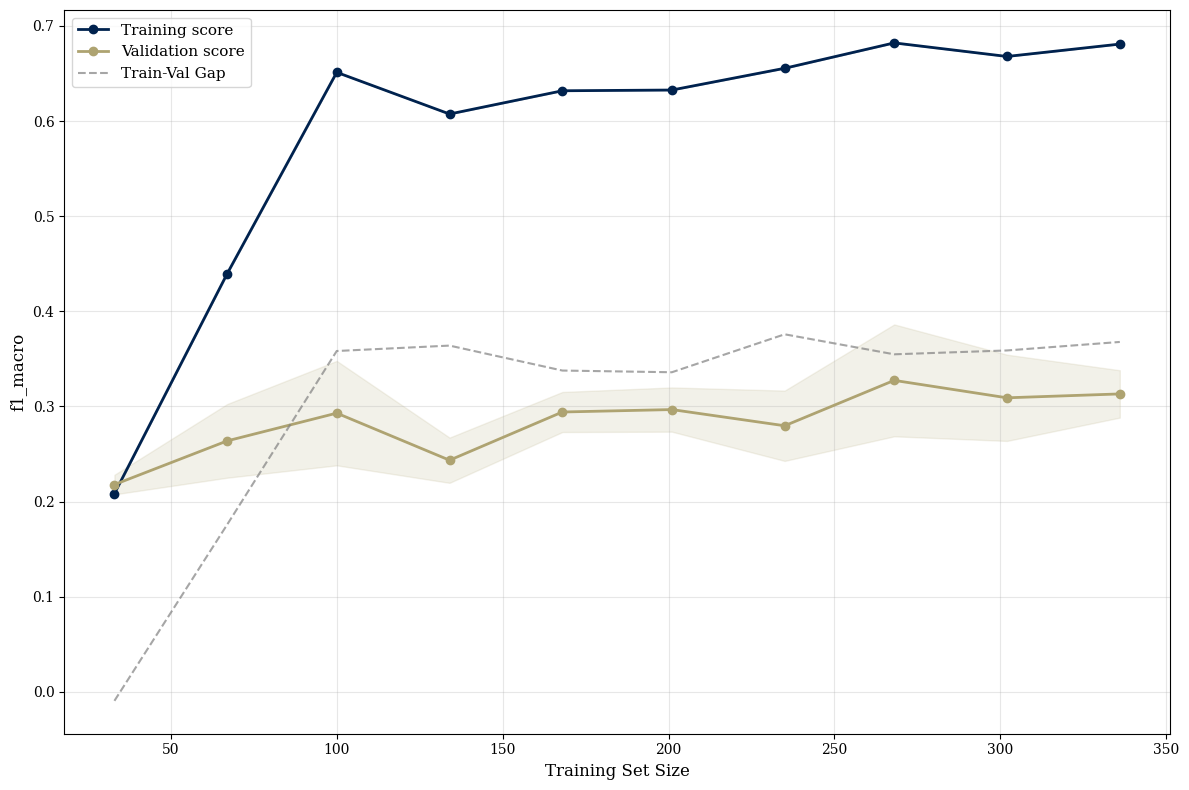

✓ Learning curves complete
✗ Learning curve generation failed: name 'final_train' is not defined



In [18]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Use uncalibrated model for learning curve (calibrated model doesn't support set_params)
    xgb_for_learning_curve = clone(best_xgb_model_uncalibrated)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Remove early stopping for learning curves (no validation set available in learning_curve)
    xgb_for_learning_curve.set_params(early_stopping_rounds=None)
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data with 3-class encoding
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = best_xgb_label_encoder.transform(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost 3-Class Classifier'
    )

## 14. Stage 5: Model Evaluation

This cell tests the best XGBoost model on completely unseen test data (data the model has never encountered during training or validation). It calculates:
- **Overall accuracy**: Percentage of correct predictions
- **Macro F1-score**: Balanced performance across all three classes
- **Confusion matrix**: Shows which classes the model confuses with each other
- **Per-class recall**: How many true Long/Neutral/Short cases were correctly identified
- **Predictions per class**: How often the model predicts each class

This gives a realistic picture of how well the model will perform in the real world.

In [19]:
# Evaluate XGBoost on test set using helper function
if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# First, tune neutral threshold on validation set
print("Tuning neutral class threshold on validation set...")
val_df = best_dataset["val_df"]
X_val = val_df[best_xgb_feature_columns].fillna(0)
y_val_raw = val_df[cfg.TARGET_COLUMN].astype(int)
y_val = best_xgb_label_encoder.transform(y_val_raw)

# Find neutral class index
neutral_class_idx = None
for i, class_label in enumerate(best_xgb_label_encoder.classes_):
    if class_label == 0:
        neutral_class_idx = i
        break

if neutral_class_idx is None:
    raise ValueError("Could not find neutral class (0) in label encoder classes")

# Tune threshold
threshold_results = model_utils.tune_neutral_threshold(
    model=best_xgb_model,
    X_val=X_val,
    y_val=y_val,
    neutral_class_idx=neutral_class_idx,
    threshold_range=(0.1, 0.5),
    n_thresholds=20
)

best_neutral_threshold = threshold_results["best_threshold"]

# Evaluate with argmax (baseline)
print("\n" + "="*70)
print("BASELINE EVALUATION (Argmax)")
print("="*70)
xgb_test_results_argmax = model_utils.evaluate_xgb_test_set(
    model=best_xgb_model,
    test_df=best_dataset["test_df"],
    feature_columns=best_xgb_feature_columns,
    target_column=cfg.TARGET_COLUMN,
    label_encoder=best_xgb_label_encoder,
    model_name="XGBoost (Argmax)",
    neutral_threshold=None
)

# Evaluate with threshold-based prediction
print("\n" + "="*70)
print("THRESHOLD-BASED EVALUATION")
print("="*70)
xgb_test_results = model_utils.evaluate_xgb_test_set(
    model=best_xgb_model,
    test_df=best_dataset["test_df"],
    feature_columns=best_xgb_feature_columns,
    target_column=cfg.TARGET_COLUMN,
    label_encoder=best_xgb_label_encoder,
    model_name="XGBoost (Threshold)",
    neutral_threshold=best_neutral_threshold
)

# Extract for downstream use (use threshold-based results)
y_test = xgb_test_results["y_test"]
y_pred = xgb_test_results["y_pred"]
y_pred_proba = xgb_test_results["y_pred_proba"]
X_test_xgb = xgb_test_results["X_test"]

Tuning neutral class threshold on validation set...

NEUTRAL THRESHOLD TUNING
  Tested 20 thresholds from 0.10 to 0.50
  Best threshold: 0.142
  Best macro-F1: 0.4057


BASELINE EVALUATION (Argmax)

✓ XGBoost (Argmax) Test Evaluation (3-class)
  argmax predictions → Acc=0.5268, Macro-F1=0.3748

CLASS-WISE METRICS: XGBoost (Argmax) Test Set (argmax)

Confusion Matrix:
[[1279    0  587]
 [ 332    0  241]
 [ 913    0 1029]]

Per-Class Recall:
  Class -1: 0.685 (1279/1866)
  Class 0: 0.000 (0/573)
  Class 1: 0.530 (1029/1942)

Classification Report:
              precision    recall  f1-score   support

          -1       0.51      0.69      0.58      1866
           0       0.00      0.00      0.00       573
           1       0.55      0.53      0.54      1942

    accuracy                           0.53      4381
   macro avg       0.35      0.41      0.37      4381
weighted avg       0.46      0.53      0.49      4381


Predictions per class:
  Class -1: 2524 predictions (57.6%)
  Clas

## 15. Visualizations

These cells create diagnostic plots for the XGBoost model:
1. **Confusion matrix**: A color-coded grid showing actual vs predicted classes, revealing which types of errors the model makes
2. **ROC curves**: One curve per class showing the model's ability to distinguish between classes (line closer to top-left = better performance)
3. **Feature importance**: Bar chart ranking which features matter most to the model's decisions (e.g., are news signals more important than price history?)

These visualizations help you understand what the model learned and where it struggles.

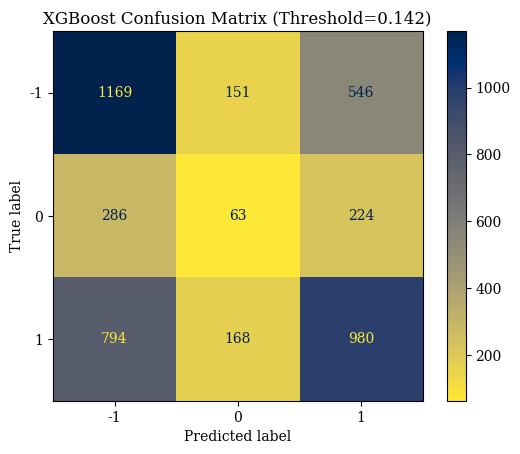

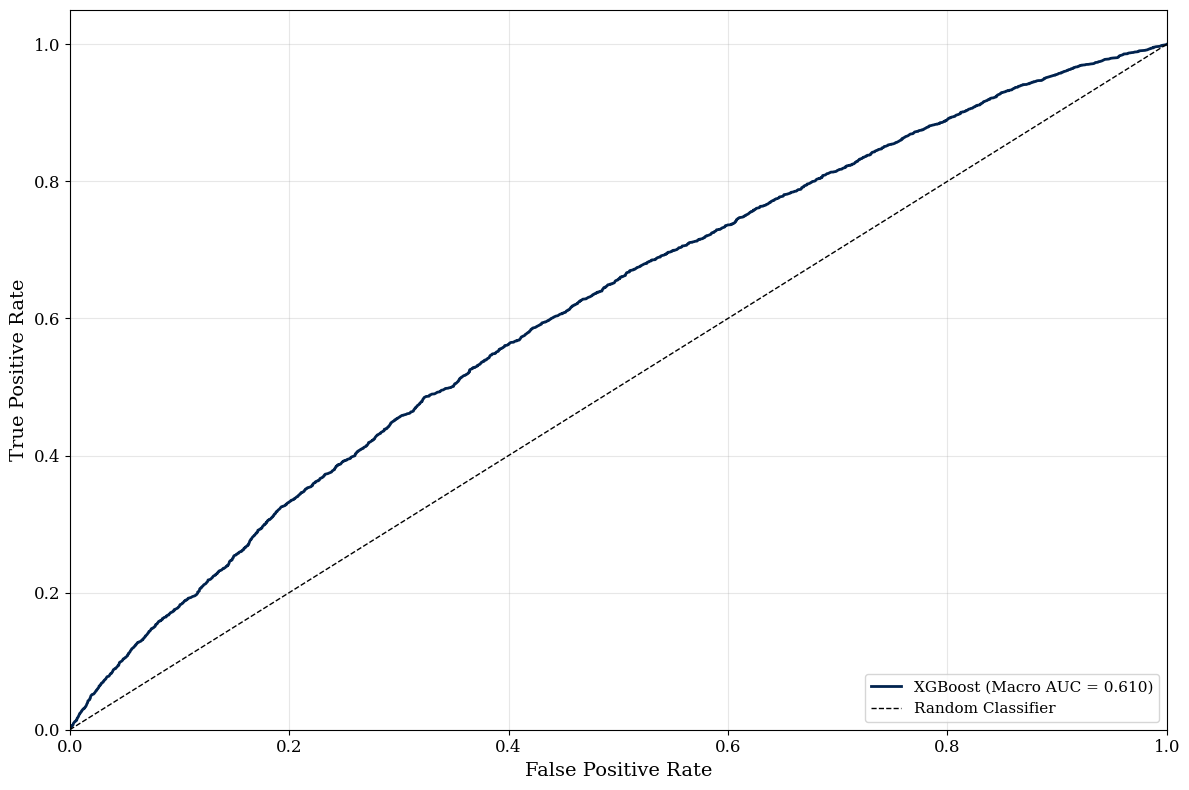

XGBoost Macro AUC: 0.610


In [20]:
# Confusion matrix (3-class) - Using threshold-based predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_xgb_label_encoder.classes_
)
disp.plot(cmap='cividis_r', values_format='d')
plt.title(f'XGBoost Confusion Matrix (Threshold={best_neutral_threshold:.3f})')
plt.show()

# ROC Curves for XGBoost
xgb_auc_scores = visualization.plot_roc_curves(
    models_dict={"XGBoost": (best_xgb_model, X_test_xgb)},
    y_test=y_test,
    label_encoder=best_xgb_label_encoder
)
print(f"XGBoost Macro AUC: {xgb_auc_scores.get('XGBoost', 'N/A'):.3f}")

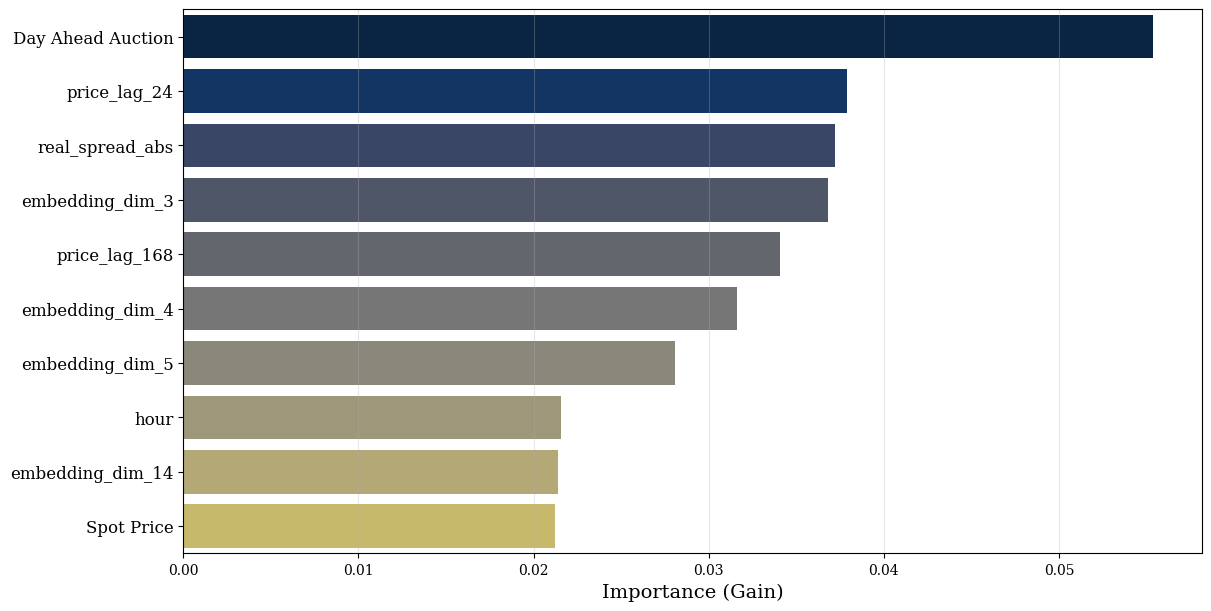

In [21]:
# Feature importance (use uncalibrated model since CalibratedClassifierCV doesn't expose feature_importances_)
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model_uncalibrated,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=10
)

## 16. Stage 6: LightGBM Signal Modelling

This stage trains two competing LightGBM models to test if the XGBoost predictions actually add value:

**Cell 34-35**: Prepares datasets by adding XGBoost predictions as new features. The "signal model" uses baseline price features + XGBoost predictions, while the "baseline model" uses only basic price/temporal features. Targets are encoded numerically for the model.

**Cell 36**: Trains both models using grid search to find the best hyperparameters. Each model is tested with 5-fold expanding-window cross-validation. Class imbalance is handled automatically with balanced class weights.

**Cell 37-38**: Evaluates both models on validation and test sets, showing detailed per-class metrics. By comparing the two models, we can see if adding XGBoost predictions (and thus news signals) improves performance beyond just using price history.

This two-stage approach (XGBoost → LightGBM) is like having two specialists review the same problem for better accuracy.

In [22]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=lgbm_baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 7
  Baseline feature count: 3
  XGBoost features added: ['xgb_pred', 'xgb_prob_class0', 'xgb_prob_class1', 'xgb_prob_class2']


In [23]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [24]:
# Configure device for LightGBM
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}")

# Train both signal and baseline LightGBM models (class imbalance handled via is_unbalance=True and class_weight='balanced')
with profiling.StageProfiler("Stage 6: LightGBM Signal & Baseline Models", device_config):
    lgbm_results = model_utils.train_lightgbm_pair(
        signal_train_df=signal_train_df,
        signal_val_df=signal_val_df,
        signal_test_df=signal_test_df,
        signal_feature_columns=signal_feature_columns,
        baseline_feature_columns=baseline_feature_columns,
        y_train=y_train_signal,
        y_val=y_val_signal,
        y_test=y_test_signal,
        label_encoder=label_encoder,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        n_cv_splits=cfg.N_CV_SPLITS,
        cv_step_size=cfg.DEFAULT_EXPANDING_STEP,
        cv_min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE
    )

# Extract trained models and artifacts
signal_best_lgbm = lgbm_results["signal_model"]
baseline_best_lgbm = lgbm_results["baseline_model"]
signal_column_rename_map = lgbm_results["signal_column_rename_map"]
baseline_column_rename_map = lgbm_results["baseline_column_rename_map"]
lgbm_artifacts = lgbm_results["evaluation"]
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]

✓ CUDA detected: NVIDIA H200 (139.7 GB)
  Optimal batch size: 512
  XGBoost tree method: hist • device: cuda
  Parallel jobs: 119
LightGBM device: CUDA (NVIDIA H200) • backend=gpu • jobs=119

[Stage ⏳] Stage 6: LightGBM Signal & Baseline Models — starting

TRAINING LIGHTGBM SIGNAL & BASELINE MODELS
Training SIGNAL model (baseline features + XGBoost predictions)...
☑ Running LightGBM GridSearchCV serially to avoid GPU thread oversubscription.


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


✓ Signal model trained - Best CV macro-F1: 0.268
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Training BASELINE model (price/temporal features only)...
☑ Running LightGBM GridSearchCV serially to avoid GPU thread oversubscription.
✓ Baseline model trained - Best CV macro-F1: 0.191
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Evaluating both models on validation and test sets...
✓ LightGBM validation performance
  Signal model  → Acc=0.443, Macro-F1=0.393
  Baseline model → Acc=0.402, Macro-F1=0.375

[Stage ✅] Stage 6: LightGBM Signal & Baseline Models — completed in 603.49s
  CPU usage: 19.9% • IO wait: 0.00%
  Disk Δ: +11663.1 MB read, +4172.4 MB written
  GPU util: 4% • Mem util: 0% (2.32/140.40 GB)


In [25]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.443, Macro-F1=0.393
  Baseline model → Acc=0.402, Macro-F1=0.375


In [26]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Decode predictions for display
signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

# Compute test metrics
signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=signal_test_pred, label_encoder=label_encoder, dataset_name="LightGBM SIGNAL Model - Test Set")
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=baseline_test_pred, label_encoder=label_encoder, dataset_name="LightGBM BASELINE Model - Test Set")

✓ LightGBM Test Performance
  Signal model  → Acc=0.451, Macro-F1=0.411
  Baseline model → Acc=0.373, Macro-F1=0.366


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[905 482 479]
 [200 187 186]
 [562 495 885]]

Per-Class Recall:
  Class -1: 0.485 (905/1866)
  Class 0: 0.326 (187/573)
  Class 1: 0.456 (885/1942)

Classification Report:
              precision    recall  f1-score   support

          -1       0.54      0.48      0.51      1866
           0       0.16      0.33      0.22       573
           1       0.57      0.46      0.51      1942

    accuracy                           0.45      4381
   macro avg       0.42      0.42      0.41      4381
weighted avg       0.51      0.45      0.47      4381


Predictions per class:
  Class -1: 1667 predictions (38.1%)
  Class 0: 1164 predictions (26.6%)
  Class 1: 1550 predictions (35.4%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[633 815 418]
 [109 306 158]
 [323 926 693]]


## 17. LightGBM Model Diagnostics

These cells create visualizations comparing the Signal and Baseline LightGBM models:

**Cell 39**: Side-by-side confusion matrices showing prediction errors for both models

**Cell 40**: ROC curves measuring each model's ability to separate the three classes, with AUC scores (higher = better)

**Cell 41**: Statistical comparison using McNemar's test and bootstrap confidence intervals to determine if the signal model is genuinely better than baseline or if differences are just random chance

**Cell 42**: Feature importance plots showing which inputs drive each model's decisions, including SHAP analysis (advanced technique showing how features interact)

Figure saved: outputs/figures/lgbm_confusion_matrices.png


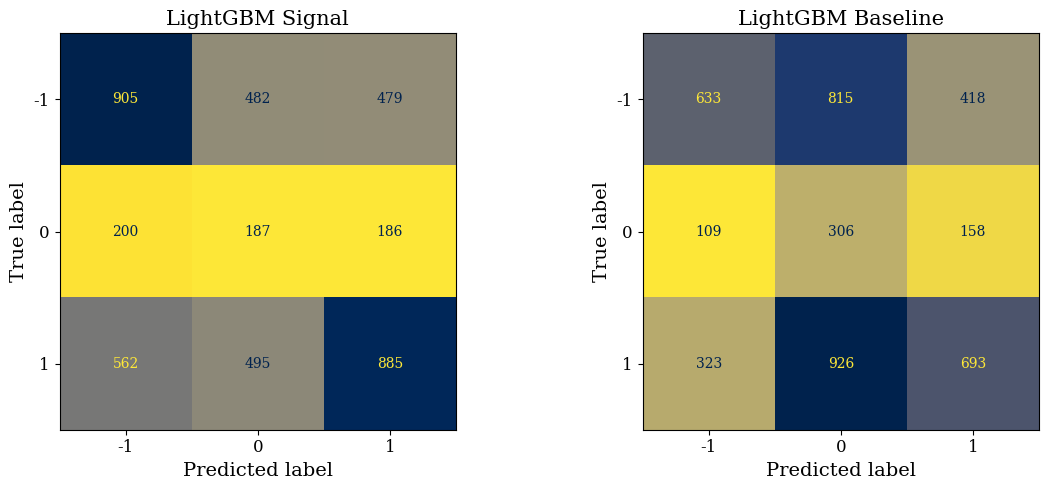

In [27]:
# Side-by-side confusion matrices for LightGBM models
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder,
    save_path="lgbm_confusion_matrices",
    show=True
)

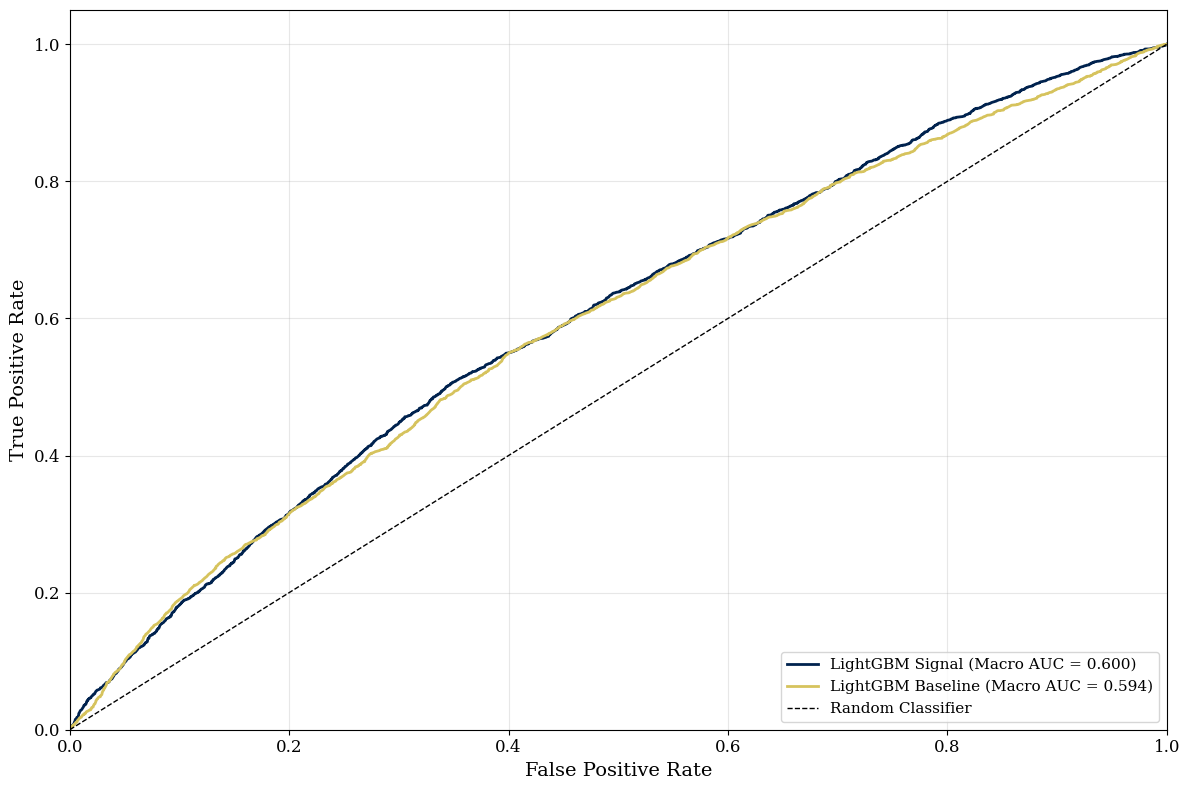

LightGBM Signal Macro AUC: 0.600
LightGBM Baseline Macro AUC: 0.594


In [28]:
# ROC Curves for LightGBM models
lgbm_auc_scores = visualization.plot_roc_curves(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder
)
print(f"LightGBM Signal Macro AUC: {lgbm_auc_scores.get('LightGBM Signal', 'N/A'):.3f}")
print(f"LightGBM Baseline Macro AUC: {lgbm_auc_scores.get('LightGBM Baseline', 'N/A'):.3f}")

In [29]:
# Statistical comparison between signal and baseline models
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
display(statistical_results)


STATISTICAL MODEL COMPARISON

Signal accuracy:   0.4513
Baseline accuracy: 0.3725

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       1285
Only signal correct:       692
Only baseline correct:     347
Both models wrong:         2057

Signal model correct:      1977
Baseline model correct:    1632

McNemar's χ² statistic:    113.8941
p-value:                   0.0000

✓ Signal model is HIGHLY SIGNIFICANTLY better (p < 0.001) ***


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.4512 [0.4360, 0.4663]
Baseline model: 0.3726 [0.3579, 0.3862]
Difference:     +0.0786

✓ Confidence intervals do NOT overlap - strong evidence of difference




{'mcnemar_statistic': np.float64(113.89412897016362),
 'mcnemar_p_value': np.float64(0.0),
 'signal_acc_mean': np.float64(0.45121364985163204),
 'signal_acc_ci': (np.float64(0.4359735220269345),
  np.float64(0.46633188769687284)),
 'baseline_acc_mean': np.float64(0.372593015293312),
 'baseline_acc_ci': (np.float64(0.3579034467016663),
  np.float64(0.38621319333485504))}

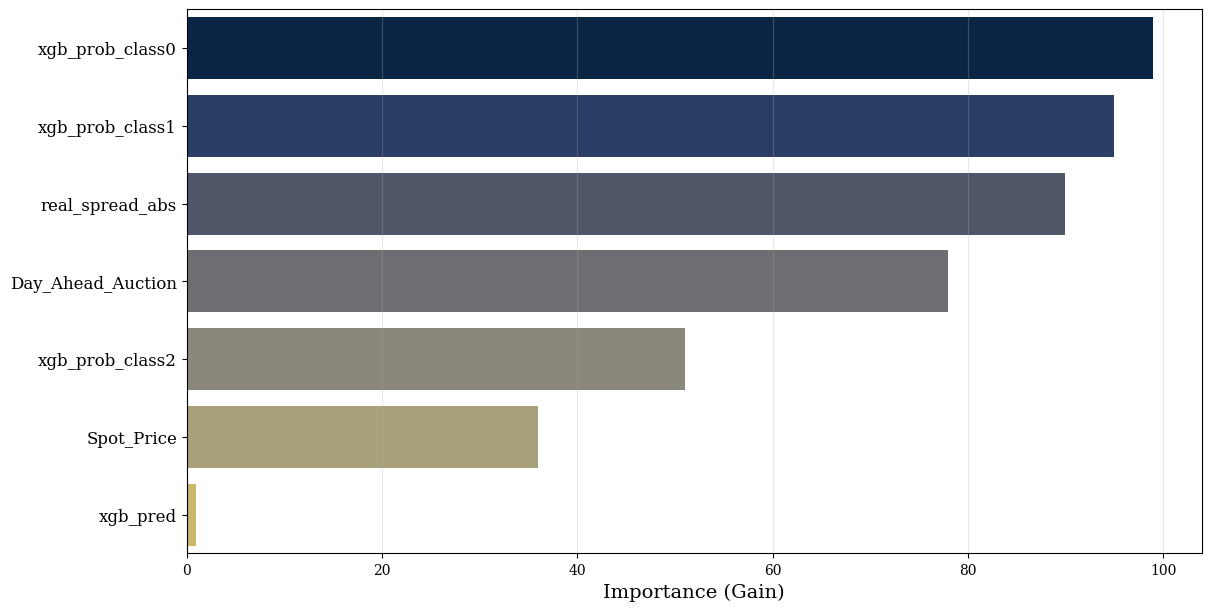

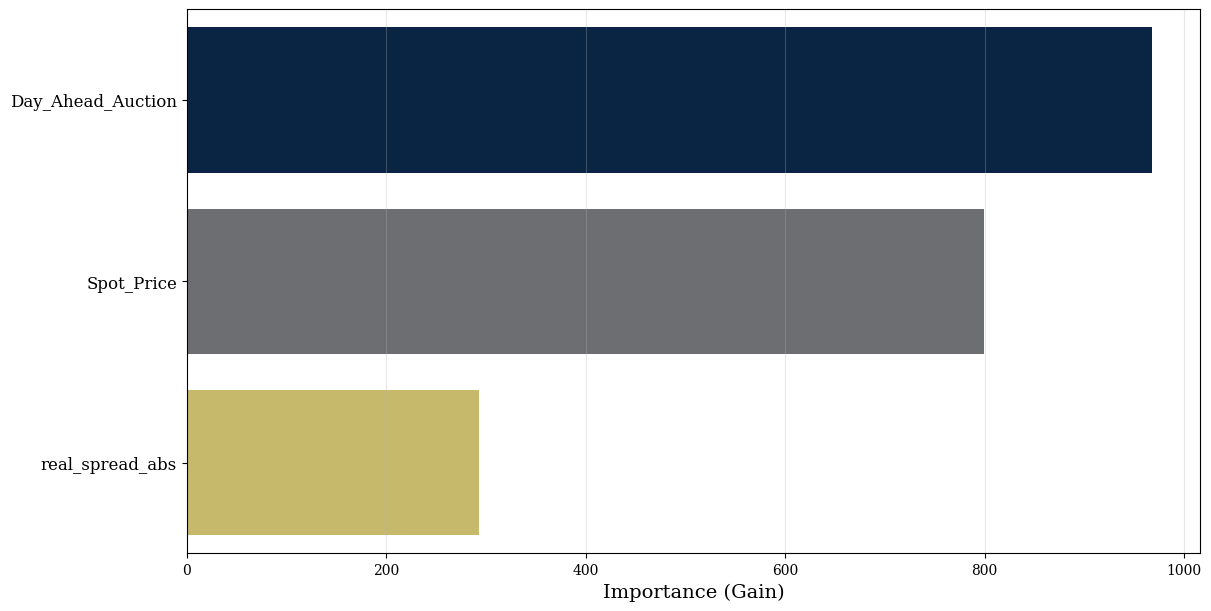


COMPUTING SHAP VALUES FOR LIGHTGBM SIGNAL MODEL
SHAP visualization failed: can't set attribute 'feature_names_in_'

COMPUTING SHAP VALUES FOR LIGHTGBM BASELINE MODEL
SHAP visualization failed: can't set attribute 'feature_names_in_'


In [30]:
# Feature importance for LightGBM models
signal_feature_columns_sanitized = list(signal_column_rename_map.values())
baseline_feature_columns_sanitized = list(baseline_column_rename_map.values())

visualization.plot_feature_importance(
    model=signal_best_lgbm,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
    top_n=20,
)
visualization.plot_feature_importance(
    model=baseline_best_lgbm,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
    top_n=20,
)

# SHAP feature importance
visualization.plot_feature_importance_shap(
    model=signal_best_lgbm,
    X_test=test_signal_X,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
)
visualization.plot_feature_importance_shap(
    model=baseline_best_lgbm,
    X_test=test_baseline_X,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
)

## 18. Portfolio Backtest Analysis

These cells simulate realistic trading with a portfolio starting at €100,000:

**Cell 49**: Runs portfolio-based backtests for both signal and baseline models. Each trade allocates 10% of current portfolio value, with realistic transaction costs (€0.50/MWh + 0.05%). Shows equity curves and summary metrics including total return, Sharpe ratio, max drawdown, and win rate.

**Cell 50**: Equity curve visualization showing portfolio value over time for both strategies, with initial capital reference line.

**Cell 51**: Drawdown analysis showing portfolio drawdowns from peak value, revealing periods of underperformance.

This answers the critical question: "Would using this model to trade actually make money with realistic costs and position sizing?"

In [31]:
import importlib
importlib.reload(evaluation)


<module 'scripts.evaluation' from '/workspace/scripts/evaluation.py'>

In [32]:
# Portfolio Backtest Configuration
INITIAL_CAPITAL = 100_000  # EUR
POSITION_PCT = 0.10        # 10% of portfolio per trade
FIXED_COST = 0.50          # EUR/MWh
PCT_COST = 0.0005          # 0.05%

# Run backtests for each strategy
signal_backtest = evaluation.run_portfolio_backtest(
    test_df=signal_test_df,
    predictions=signal_test_pred,
    label_encoder=label_encoder,
    initial_capital=INITIAL_CAPITAL,
    position_pct=POSITION_PCT,
    fixed_cost_per_mwh=FIXED_COST,
    pct_cost=PCT_COST,
)

baseline_backtest = evaluation.run_portfolio_backtest(
    test_df=signal_test_df,
    predictions=baseline_test_pred,
    label_encoder=label_encoder,
    initial_capital=INITIAL_CAPITAL,
    position_pct=POSITION_PCT,
    fixed_cost_per_mwh=FIXED_COST,
    pct_cost=PCT_COST,
)

# Naive strategy: Always Long (buy at day-ahead, sell at spot)
# Predictions are encoded: 0=-1 (Short), 1=0 (Neutral), 2=1 (Long)
# For "always Long", we need to predict class 2 (which decodes to +1)
naive_predictions = np.full_like(signal_test_pred, fill_value=2)  # Always predict Long (encoded as 2)

naive_backtest = evaluation.run_portfolio_backtest(
    test_df=signal_test_df,
    predictions=naive_predictions,
    label_encoder=label_encoder,
    initial_capital=INITIAL_CAPITAL,
    position_pct=POSITION_PCT,
    fixed_cost_per_mwh=FIXED_COST,
    pct_cost=PCT_COST,
)

# Display summary
print(f"Portfolio Backtest Configuration:")
print(f"  Initial Capital: €{INITIAL_CAPITAL:,.0f}")
print(f"  Position Size: {POSITION_PCT*100:.0f}% per trade")
print(f"  Transaction Costs: €{FIXED_COST}/MWh + {PCT_COST*100:.2f}%")
print()

summary = pd.DataFrame({
    "Signal Model": signal_backtest["metrics"],
    "Baseline Model": baseline_backtest["metrics"],
    "Naive (Always Long)": naive_backtest["metrics"],
}).T
display(summary)

Portfolio Backtest Configuration:
  Initial Capital: €100,000
  Position Size: 10% per trade
  Transaction Costs: €0.5/MWh + 0.05%



,Final Value (EUR),Total Return (%),Annualized Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Win Rate (%),Total Trades,Trades Capped,Total Costs (EUR)
Signal Model,2.760445e+06,2660.445002,75985.231512,1552.470408,2197.077387,-4.044048,61.361517,3217.0,642.0,313329.149977
Baseline Model,2.349169e+06,2249.169296,55006.494683,1059.350261,1561.203609,-3.987645,62.167952,2334.0,554.0,226146.039396
Naive (Always Long),1.319060e+04,-86.809399,-98.258471,-1.218090,-3.175442,-95.113746,49.623374,4381.0,2760.0,174609.366936


Figure saved: outputs/figures/equity_curve.png


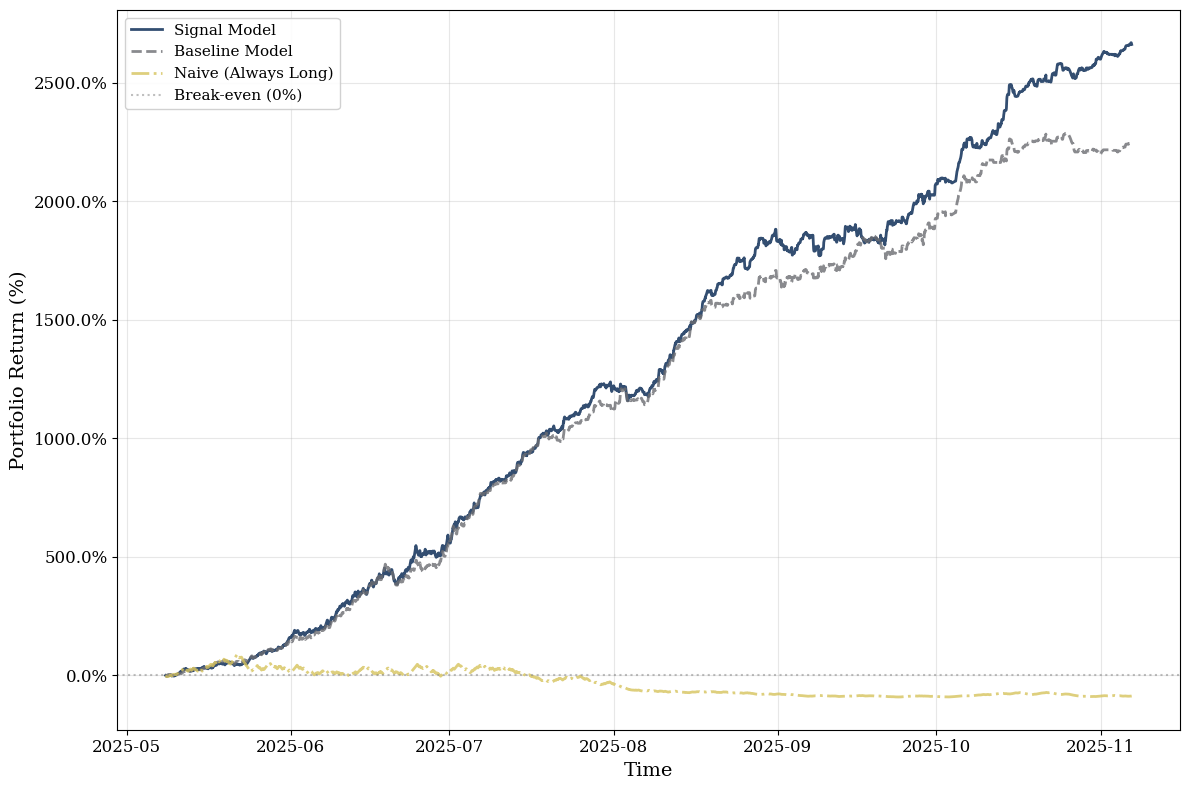

In [33]:
# Plot equity curves (showing % returns)
visualization.plot_equity_curve(
    equity_curves={
        "Signal Model": signal_backtest["equity_curve"],
        "Baseline Model": baseline_backtest["equity_curve"],
        "Naive (Always Long)": naive_backtest["equity_curve"],
    },
    initial_capital=INITIAL_CAPITAL,
    title="Portfolio Equity Curve - Test Period",
    save_path="equity_curve",
    show_pct_return=True,  # Display percentage returns instead of absolute EUR
)

Figure saved: outputs/figures/portfolio_drawdown.png


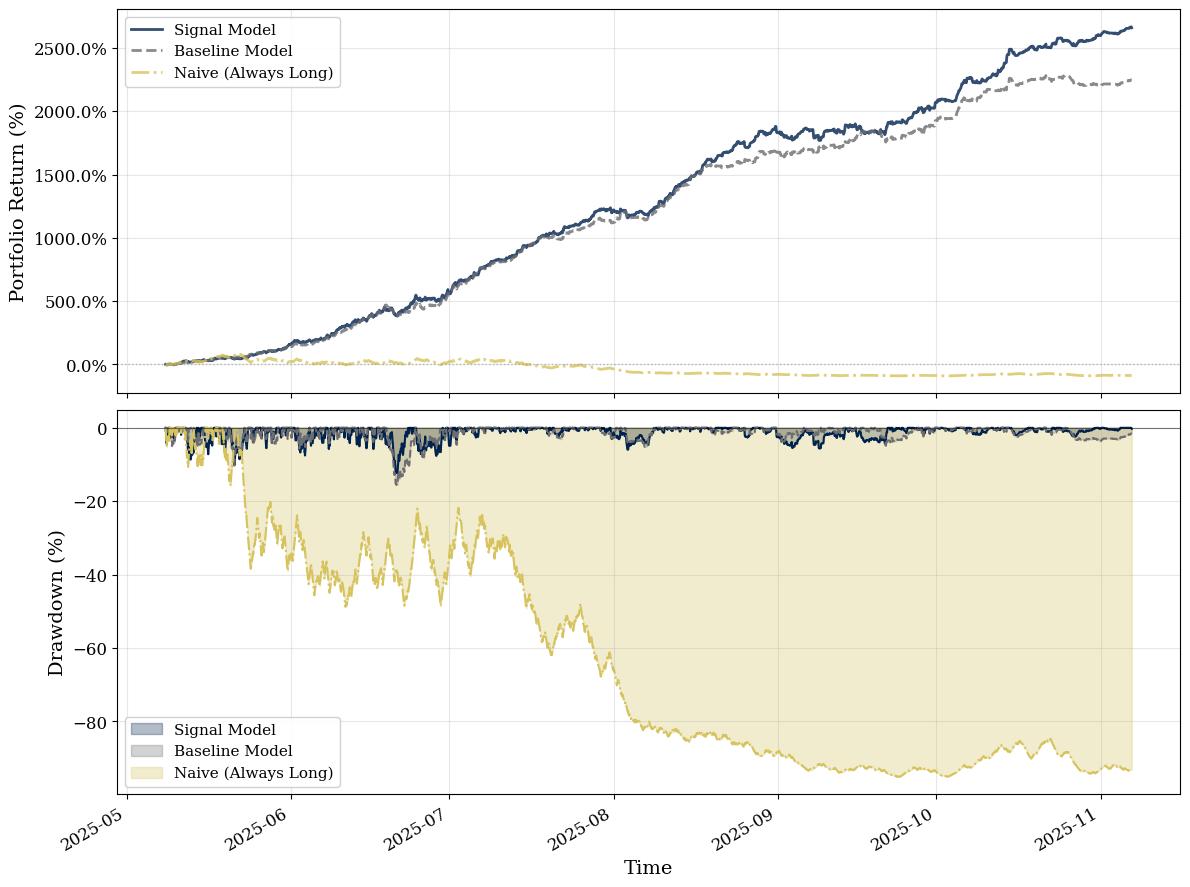

In [34]:
# Plot drawdown analysis (showing % returns)
visualization.plot_portfolio_drawdown(
    equity_curves={
        "Signal Model": signal_backtest["equity_curve"],
        "Baseline Model": baseline_backtest["equity_curve"],
        "Naive (Always Long)": naive_backtest["equity_curve"],
    },
    initial_capital=INITIAL_CAPITAL,
    title="Portfolio Drawdown Analysis - Test Period",
    save_path="portfolio_drawdown",
    show_pct_return=True,  # Display percentage returns instead of absolute EUR
)

In [35]:
# Analyze equity tail to investigate large drops
# Check if there's a significant drop in the final periods
final_20_periods_start = signal_backtest["equity_curve"].iloc[-20]
final_value = signal_backtest["equity_curve"].iloc[-1]
drop_pct = ((final_value - final_20_periods_start) / final_20_periods_start) * 100

if abs(drop_pct) > 5:  # If drop > 5% in last 20 periods
    print(f"⚠ Significant change detected in final 20 periods: {drop_pct:+.2f}%")
    print("Analyzing tail period...\n")
    evaluation.analyze_equity_tail(
        signal_backtest,
        n_periods=20,
        initial_capital=INITIAL_CAPITAL,
    )
else:
    print(f"✓ No significant drop detected in final periods ({drop_pct:+.2f}%)")


✓ No significant drop detected in final periods (+0.16%)
